In [55]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from io import BytesIO
from zipfile import ZipFile
from time import time
import sklearn
from skimage import io
from skimage.color import rgb2gray
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import NMF, LatentDirichletAllocation
from matplotlib.image import imread
import glob
import warnings

warnings.filterwarnings('ignore')

RANDOM_SEED = 123

In [56]:
data_df = pd.read_csv('data.csv')
data_df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [57]:
data_df.shape

(30000, 25)

In [58]:
data_df.dtypes

ID                            int64
LIMIT_BAL                     int64
SEX                           int64
EDUCATION                     int64
MARRIAGE                      int64
AGE                           int64
PAY_0                         int64
PAY_2                         int64
PAY_3                         int64
PAY_4                         int64
PAY_5                         int64
PAY_6                         int64
BILL_AMT1                     int64
BILL_AMT2                     int64
BILL_AMT3                     int64
BILL_AMT4                     int64
BILL_AMT5                     int64
BILL_AMT6                     int64
PAY_AMT1                      int64
PAY_AMT2                      int64
PAY_AMT3                      int64
PAY_AMT4                      int64
PAY_AMT5                      int64
PAY_AMT6                      int64
default payment next month    int64
dtype: object

In [59]:
data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_AMT3        

In [60]:
"""
The page for this dataset: https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients
Says there is no missing values, but we will check anyways.
"""
data_df.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

In [61]:
data_df.drop(columns=['ID']).describe(include='all')

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [62]:
# handle renaming (the last column is really the only one that matters for simplicity)
data_df = data_df.rename(columns={'ID': 'id'})
data_df = data_df.rename(columns={'LIMIT_BAL': 'limit_bal'})
data_df = data_df.rename(columns={'SEX': 'sex'})
data_df = data_df.rename(columns={'EDUCATION': 'education'})
data_df = data_df.rename(columns={'MARRIAGE': 'marriage'})
data_df = data_df.rename(columns={'AGE': 'age'})
data_df = data_df.rename(columns={'PAY_0': 'pay_1'}) # it goes pay_0 to pay_2, so I am renaming to pay_1 for consistency
data_df = data_df.rename(columns={'PAY_2': 'pay_2'})
data_df = data_df.rename(columns={'PAY_3': 'pay_3'})
data_df = data_df.rename(columns={'PAY_4': 'pay_4'})
data_df = data_df.rename(columns={'PAY_5': 'pay_5'})
data_df = data_df.rename(columns={'PAY_6': 'pay_6'})
data_df = data_df.rename(columns={'BILL_AMT1': 'bill_amt1'})
data_df = data_df.rename(columns={'BILL_AMT2': 'bill_amt2'})
data_df = data_df.rename(columns={'BILL_AMT3': 'bill_amt3'})
data_df = data_df.rename(columns={'BILL_AMT4': 'bill_amt4'})
data_df = data_df.rename(columns={'BILL_AMT5': 'bill_amt5'})
data_df = data_df.rename(columns={'BILL_AMT6': 'bill_amt6'})
data_df = data_df.rename(columns={'PAY_AMT1': 'pay_amt1'})
data_df = data_df.rename(columns={'PAY_AMT2': 'pay_amt2'})
data_df = data_df.rename(columns={'PAY_AMT3': 'pay_amt3'})
data_df = data_df.rename(columns={'PAY_AMT4': 'pay_amt4'})
data_df = data_df.rename(columns={'PAY_AMT5': 'pay_amt5'})
data_df = data_df.rename(columns={'PAY_AMT6': 'pay_amt6'})
data_df = data_df.rename(columns={'default payment next month': 'default'})

In [63]:
# explicit casting of data types for consistency
data_df['id'] = data_df['id'].astype('int64')
data_df['limit_bal'] = data_df['limit_bal'].astype('int64')
data_df['sex'] = data_df['sex'].astype('category')
data_df['education'] = data_df['education'].astype('category')
data_df['marriage'] = data_df['marriage'].astype('category')
data_df['age'] = data_df['age'].astype('int64')
data_df['pay_1'] = data_df['pay_1'].astype('int64')
data_df['pay_2'] = data_df['pay_2'].astype('int64')
data_df['pay_3'] = data_df['pay_3'].astype('int64')
data_df['pay_4'] = data_df['pay_4'].astype('int64')
data_df['pay_5'] = data_df['pay_5'].astype('int64')
data_df['pay_6'] = data_df['pay_6'].astype('int64')
data_df['bill_amt1'] = data_df['bill_amt1'].astype('int64')
data_df['bill_amt2'] = data_df['bill_amt2'].astype('int64')
data_df['bill_amt3'] = data_df['bill_amt3'].astype('int64')
data_df['bill_amt4'] = data_df['bill_amt4'].astype('int64')
data_df['bill_amt5'] = data_df['bill_amt5'].astype('int64')
data_df['bill_amt6'] = data_df['bill_amt6'].astype('int64')
data_df['pay_amt1'] = data_df['pay_amt1'].astype('int64')
data_df['pay_amt2'] = data_df['pay_amt2'].astype('int64')
data_df['pay_amt3'] = data_df['pay_amt3'].astype('int64')
data_df['pay_amt4'] = data_df['pay_amt4'].astype('int64')
data_df['pay_amt5'] = data_df['pay_amt5'].astype('int64')
data_df['pay_amt6'] = data_df['pay_amt6'].astype('int64')
data_df['default'] = data_df['default'].astype('bool') # cast to boolean for simplicity (0 = False, 1 = True)

In [64]:
numeric_cols = data_df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = data_df.select_dtypes(include=['category']).columns
numeric_cols = numeric_cols.drop('id') # id isn't a predictor

In [65]:
data_df.value_counts('default')

default
False    23364
True      6636
Name: count, dtype: int64

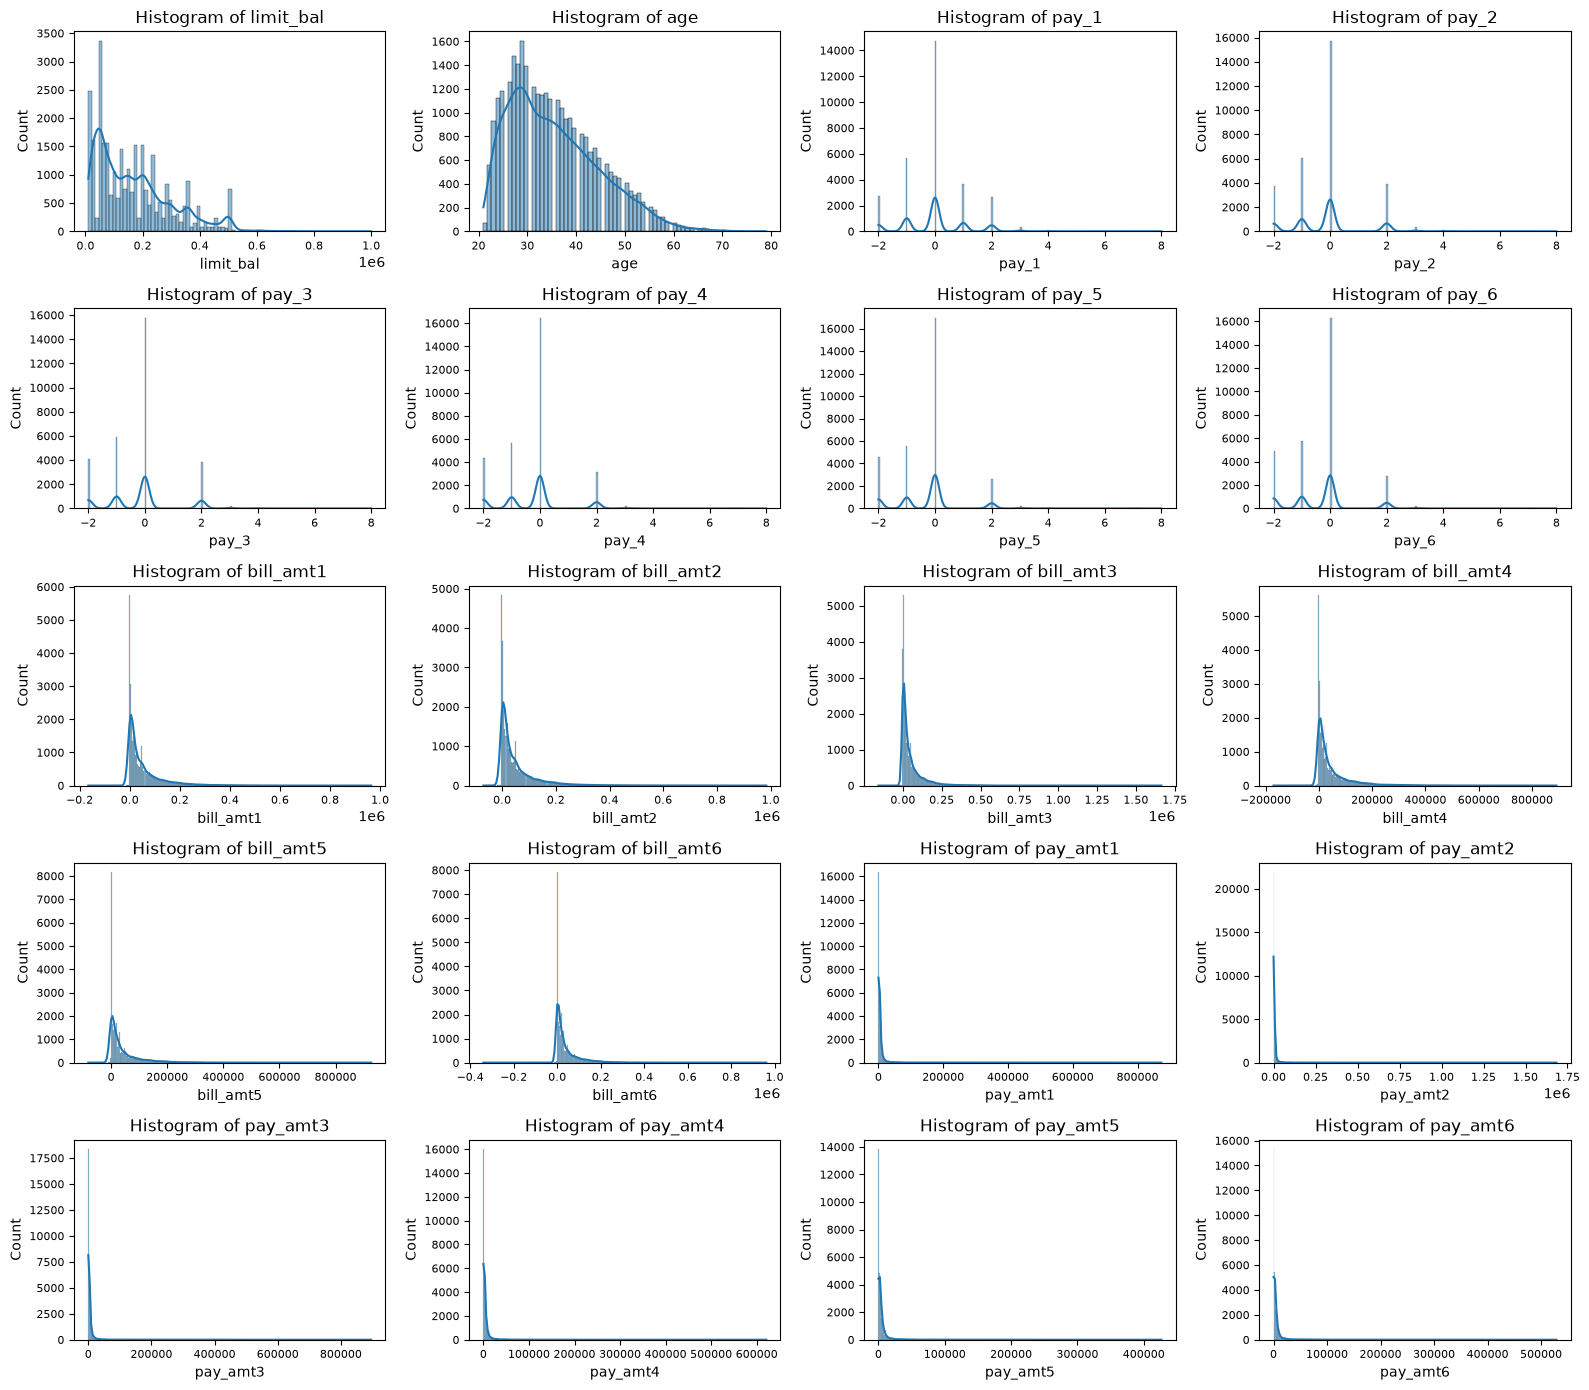

In [ ]:
# 20 numeric columns, so 5 rows x 4 cols subplots of histograms
fig, ax = plt.subplots(figsize=(16, 14), nrows=5, ncols=4)
axes = ax.flatten()

for i, column in enumerate(numeric_cols):
    sns.histplot(data=data_df, x=column, ax=axes[i], kde=True)
    axes[i].set_title(f'Histogram of {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', labelsize=8)
    axes[i].tick_params(axis='y', labelsize=8) # resize font size on axes for readability
    plt.tight_layout()
plt.show()